DO NOT CHANGE (COPY AND MADE CHAGES TO THAT FILE)

In [3]:
import re
import math
from collections import defaultdict, Counter
from tqdm import tqdm
import numpy as np


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
FILE = "/content/drive/MyDrive/all.txt"

# Try UTF-16 first
try:
    with open(FILE, "r", encoding="utf-16") as f:
        text = f.read()
        print("Loaded using UTF-16 encoding.")
except UnicodeError:
    # fallback to UTF-8 with BOM
    with open(FILE, "r", encoding="utf-8-sig") as f:
        text = f.read()
        print("Loaded using UTF-8-SIG encoding.")

print(text[:500])

Loaded using UTF-16 encoding.
N - NOUN
Pr - PRONOUN
Adj - ADJECTIVE
Adv - ADVERB
V - VERB
PREP -PREPOSITION
CON - CONJUNCTION
IN - INTERJECTION

প্ৰাচীন/Adj ভাৰতৰ/N মুদ্ৰাব্যৱস্থা/N : বিনিময়ৰ/N মাধ্যম/N হিচাপে/PREP প্ৰাচীন/Adj ভাৰতত/N মুদ্ৰা/N ব্যৱস্থাৰ/N আৰম্ভণি/N কেতিয়া/ADV  হৈছিল/V তাক/Pr সঠিককৈ/Adv কʼব/V নোৱাৰি/V। একাংশ/N ঐতিহাসিকৰ/Adj মতে/N, বৈদিক/Adj সাহিত্যত/N পোৱা/V 'কৃষ্ণল'/N, 'শতমান/N, 'নিষ্ক'/N ইত্যাদি/CON শব্দৰ/N পৰা/PREP বৈদিক/ADJ সমাজত/N মুদ্ৰা/N ব্যৱস্থাৰ/N বিকাশ/N হৈছিল/V বুলি/CON/ ধাৰণা/N কৰিব/V পাৰি/V। অৱশ্


In [7]:
raw_words = []
gold_tags = []

# Matches token/POS (POS tags are letters; adjust if your tags include digits/underscores)
pattern = re.compile(r"(\S+?)/([A-Za-z]+)")

for word, tag in pattern.findall(text):
    raw_words.append(word)
    gold_tags.append(tag)

print("Total tokens:", len(raw_words))
print("Sample:", list(zip(raw_words[:20], gold_tags[:20])))


Total tokens: 44574
Sample: [('প্ৰাচীন', 'Adj'), ('ভাৰতৰ', 'N'), ('মুদ্ৰাব্যৱস্থা', 'N'), ('বিনিময়ৰ', 'N'), ('মাধ্যম', 'N'), ('হিচাপে', 'PREP'), ('প্ৰাচীন', 'Adj'), ('ভাৰতত', 'N'), ('মুদ্ৰা', 'N'), ('ব্যৱস্থাৰ', 'N'), ('আৰম্ভণি', 'N'), ('কেতিয়া', 'ADV'), ('হৈছিল', 'V'), ('তাক', 'Pr'), ('সঠিককৈ', 'Adv'), ('কʼব', 'V'), ('নোৱাৰি', 'V'), ('একাংশ', 'N'), ('ঐতিহাসিকৰ', 'Adj'), ('মতে', 'N')]


In [8]:
gold_tags = [t.upper() for t in gold_tags]
print("Unique tags:", sorted(set(gold_tags)))


Unique tags: ['A', 'ADJ', 'ADV', 'ANU', 'B', 'C', 'CON', 'INT', 'M', 'N', 'NADJ', 'PR', 'PREP', 'S', 'V', 'VADJ']


In [9]:
trigram_counts = defaultdict(int)
bigram_counts  = defaultdict(int)

for i in range(len(raw_words) - 2):
    w1, w2, w3 = raw_words[i], raw_words[i+1], raw_words[i+2]
    trigram_counts[(w1, w2, w3)] += 1
    bigram_counts[(w1, w2)] += 1

print("Total unique bigrams :", len(bigram_counts))
print("Total unique trigrams:", len(trigram_counts))


Total unique bigrams : 37824
Total unique trigrams: 42966


In [10]:
context_prob = defaultdict(dict)

for (w1, w2, w3), c in trigram_counts.items():
    denom = bigram_counts[(w1, w2)]
    context_prob[(w1, w2)][w3] = c / denom

print("Sample context:", next(iter(context_prob.items())) if context_prob else "Empty")


Sample context: (('প্ৰাচীন', 'ভাৰতৰ'), {'মুদ্ৰাব্যৱস্থা': 0.5, 'কাল্পনিক': 0.5})


In [11]:
vocab = sorted(set(raw_words))
cluster = {w: i for i, w in enumerate(vocab)}

print("Initial clusters:", len(set(cluster.values())))
print("Initial vocab size:", len(vocab))


Initial clusters: 12405
Initial vocab size: 12405


In [12]:
pair_counter = Counter()

for (w1, w2), c in bigram_counts.items():
    # treat neighbors as potential merge candidates
    pair_counter[(w1, w2)] += c

# convert word-pairs to cluster-pairs
candidate_pairs = []
for (w1, w2), c in pair_counter.most_common(5000):  # tune this
    c1, c2 = cluster[w1], cluster[w2]
    if c1 != c2:
        candidate_pairs.append((c1, c2, c))

print("Candidate cluster-pairs:", len(candidate_pairs))


Candidate cluster-pairs: 4985


In [13]:
def build_cluster_trigram_counts(cluster, raw_words):
    """
    Returns:
      triC[(c1,c2,c3)] count
      biC[(c1,c2)] count
    """
    triC = defaultdict(int)
    biC  = defaultdict(int)

    for i in range(len(raw_words) - 2):
        c1 = cluster[raw_words[i]]
        c2 = cluster[raw_words[i+1]]
        c3 = cluster[raw_words[i+2]]
        triC[(c1,c2,c3)] += 1
        biC[(c1,c2)] += 1
    return triC, biC


def corpus_log_likelihood(triC, biC):
    """
    L = sum_{c1,c2,c3} count * log P(c3 | c1,c2)
    where P(c3|c1,c2) = triC / biC
    """
    L = 0.0
    for (c1,c2,c3), cnt in triC.items():
        denom = biC[(c1,c2)]
        p = cnt / denom
        L += cnt * math.log(p + 1e-12)
    return L


In [14]:
def apply_merge(cluster, c_from, c_into):
    """
    Return a NEW cluster dict where cluster id c_from is replaced by c_into.
    """
    new_cluster = cluster.copy()
    for w, cid in cluster.items():
        if cid == c_from:
            new_cluster[w] = c_into
    return new_cluster


def evaluate_merge(c1, c2, cluster, raw_words, triC=None, biC=None, base_L=None):
    """
    Evaluate merging c1 -> c2. Returns (gain, new_cluster).
    For speed you can pass precomputed triC,biC,base_L.
    """
    if triC is None or biC is None or base_L is None:
        triC, biC = build_cluster_trigram_counts(cluster, raw_words)
        base_L = corpus_log_likelihood(triC, biC)

    new_cluster = apply_merge(cluster, c1, c2)
    triC2, biC2 = build_cluster_trigram_counts(new_cluster, raw_words)
    new_L = corpus_log_likelihood(triC2, biC2)

    return (new_L - base_L), new_cluster


In [15]:
def evaluate_current_clustering(cluster, raw_words, gold_tags):
    cluster_pos_counts = defaultdict(Counter)

    for w, g in zip(raw_words, gold_tags):
        cluster_pos_counts[cluster[w]][g] += 1

    cluster_to_pos = {
        cid: cnt.most_common(1)[0][0]
        for cid, cnt in cluster_pos_counts.items()
    }

    predicted = [cluster_to_pos[cluster[w]] for w in raw_words]
    correct = sum(g == p for g, p in zip(gold_tags, predicted))
    return correct / len(gold_tags), cluster_to_pos, predicted


In [16]:
merge_history = []

# initial scores
triC, biC = build_cluster_trigram_counts(cluster, raw_words)
base_L = corpus_log_likelihood(triC, biC)

acc0, cluster_to_pos0, pred0 = evaluate_current_clustering(cluster, raw_words, gold_tags)
merge_history.append({
    "iteration": 0,
    "merge": None,
    "delta_L": None,
    "clusters": len(set(cluster.values())),
    "accuracy": acc0
})

MAX_ITERS = 50  # change to 100 if you want, but early stop will still stop safely

for iteration in range(1, MAX_ITERS + 1):
    best_gain = -1e18
    best_cluster = None
    best_merge = None

    # recompute base likelihood each iter from current cluster
    triC, biC = build_cluster_trigram_counts(cluster, raw_words)
    base_L = corpus_log_likelihood(triC, biC)

    for c1, c2, _ in candidate_pairs:
        if c1 == c2:
            continue
        gain, new_cluster = evaluate_merge(c1, c2, cluster, raw_words, triC, biC, base_L)
        if gain > best_gain:
            best_gain = gain
            best_cluster = new_cluster
            best_merge = (c1, c2)

    # EARLY STOP (important)
    if best_merge is None or best_gain <= 0:
        print(f"Stopping at iter {iteration}: best ΔL={best_gain:.6f}")
        break

    cluster = best_cluster

    acc, cluster_to_pos, predicted_tags = evaluate_current_clustering(cluster, raw_words, gold_tags)

    merge_history.append({
        "iteration": iteration,
        "merge": best_merge,
        "delta_L": best_gain,
        "clusters": len(set(cluster.values())),
        "accuracy": acc
    })

    print(f"Iter {iteration}: merge={best_merge}, ΔL={best_gain:.4f}, clusters={len(set(cluster.values()))}, acc={acc:.4f}")


Stopping at iter 1: best ΔL=0.000000


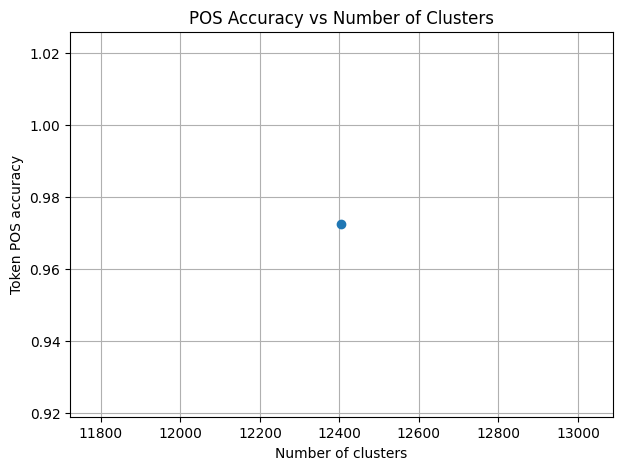

In [17]:
import matplotlib.pyplot as plt

num_clusters = [h["clusters"] for h in merge_history]
accuracies   = [h["accuracy"] for h in merge_history]

plt.figure(figsize=(7,5))
plt.plot(num_clusters, accuracies, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Token POS accuracy")
plt.title("POS Accuracy vs Number of Clusters")
plt.grid(True)
plt.show()


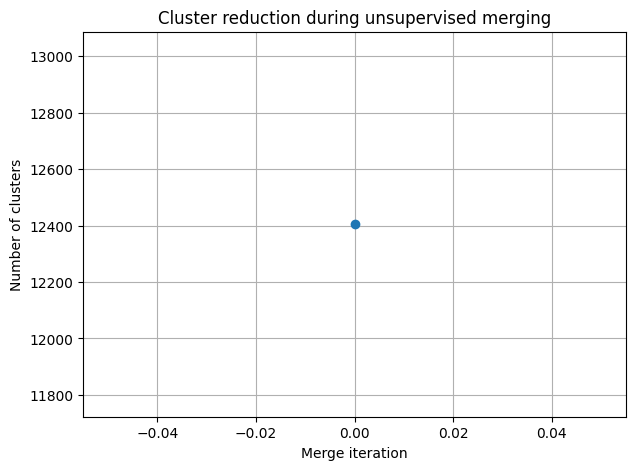

In [18]:
clusters_over_time = [h["clusters"] for h in merge_history]

plt.figure(figsize=(7,5))
plt.plot(range(len(clusters_over_time)), clusters_over_time, marker="o")
plt.xlabel("Merge iteration")
plt.ylabel("Number of clusters")
plt.title("Cluster reduction during unsupervised merging")
plt.grid(True)
plt.show()


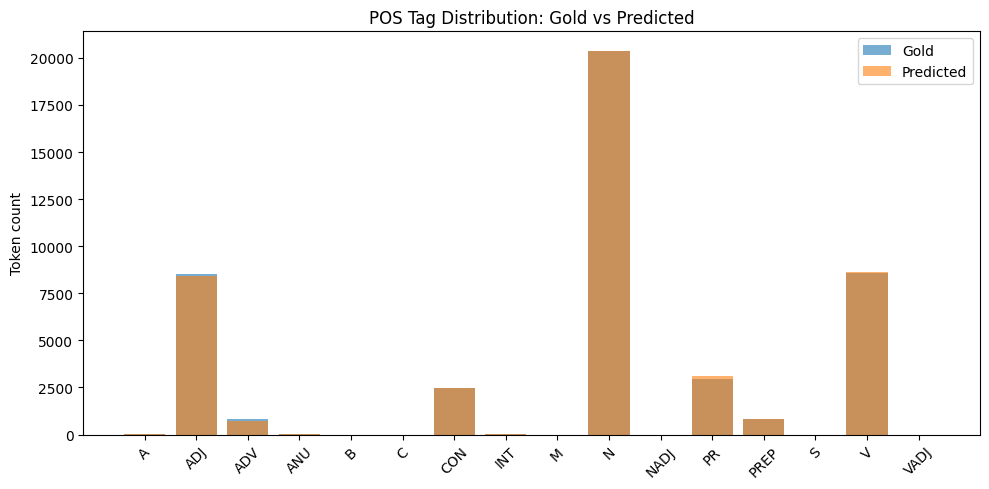

In [19]:
# predicted tags for FINAL clustering
_, _, predicted_tags = evaluate_current_clustering(cluster, raw_words, gold_tags)

gold_dist = Counter(gold_tags)
pred_dist = Counter(predicted_tags)

labels = sorted(set(gold_dist) | set(pred_dist))
gold_vals = [gold_dist[l] for l in labels]
pred_vals = [pred_dist[l] for l in labels]

plt.figure(figsize=(10,5))
plt.bar(labels, gold_vals, alpha=0.6, label="Gold")
plt.bar(labels, pred_vals, alpha=0.6, label="Predicted")
plt.xticks(rotation=45)
plt.ylabel("Token count")
plt.title("POS Tag Distribution: Gold vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
rows = []
gold = gold_tags
pred = predicted_tags

for pos in sorted(set(gold)):
    tp = sum(1 for g, p in zip(gold, pred) if g == pos and p == pos)
    fn = sum(1 for g, p in zip(gold, pred) if g == pos and p != pos)
    support = tp + fn
    acc = tp / (support + 1e-12)
    rows.append((pos, support, acc))

print(f"{'POS':<10} {'Support':>8} {'Accuracy':>10}")
print("-"*32)
for pos, sup, acc in rows:
    print(f"{pos:<10} {sup:>8} {acc:>10.3f}")


POS         Support   Accuracy
--------------------------------
A                 6      0.833
ADJ            8527      0.948
ADV             820      0.824
ANU              14      1.000
B                 1      1.000
C                 2      1.000
CON            2449      0.962
INT              18      0.944
M                 2      0.000
N             20364      0.986
NADJ              1      0.000
PR             2932      0.991
PREP            841      0.855
S                 1      1.000
V              8595      0.988
VADJ              1      0.000


In [22]:
import pandas as pd

df_hist = pd.DataFrame(merge_history)
df_hist.to_csv("merge_history.csv", index=False)
df_hist.head()


,iteration,merge,delta_L,clusters,accuracy
0,0,None,None,12405,0.972473


In [23]:
import pandas as pd
from google.colab import files

df_hist = pd.DataFrame(merge_history)
csv_path = "merge_history.csv"
df_hist.to_csv(csv_path, index=False)

files.download(csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>